# Section E11.4
The theoretical equation for the voltage across the capacitor as a function of time is as follows:
$$
V_{c}(t) = V_{in}\left( 1 - e^{- \frac{t}{RC}} \right)
\tag{1}
$$

$$RC = 2.2*10^{6}*47*10^{- 6} \tag{2}$$

$$V_{c}(t) = 30\left( 1 - e^{- \frac{t}{103.4}} \right) \tag{3}$$

The theoretical and experimental values for the voltage across the capacitor are shown below:


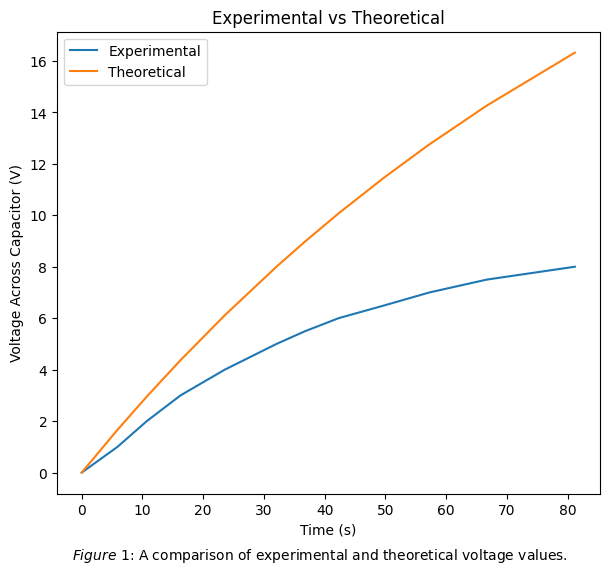

In [1]:
import matplotlib.pyplot as plt
import numpy as np

voltage_across_capacitor = np.array([0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8])
time_taken = np.array([0, 5.89, 10.72, 16.27, 23.56, 32.07, 36.83, 42.30, 49.87, 57.25, 66.70, 81.20])
plt.figure(figsize=(7, 6))
plt.plot(time_taken, voltage_across_capacitor)

# voltage across capacitor over time
# V_C = V_in(1 - e^(-t/RC))

V_in = 30
R = 2.2*(10**6)
C = 47*(10**-6)
theoretical_V_C = V_in*(1 - np.exp(-time_taken/(R*C)))
plt.plot(time_taken, theoretical_V_C)
plt.xlabel("Time (s)"); plt.ylabel("Voltage Across Capacitor (V)")
plt.title("Experimental vs Theoretical")
plt.legend(["Experimental", "Theoretical"])
caption = r"$\it{Figure~1}$: A comparison of experimental and theoretical voltage values."
plt.figtext(0.5, 0.001, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.show()


Evidently, there is a significant deviation from the experimental results. The two curves start off close yet quickly diverge as time moves on. For example, at the 81.23-second mark, the practical and theoretical voltages are 8 and 16.32 volts, respectively. The calculated percentage error is around 51%, too high to be acceptable.
While this could be due to poor experimental practice, it is more likely that the circuit diagram is not accurate enough and that other factors will need to be considered. To do so, the internal resistance of the oscilloscope will be considered (1MΩ) [1]. Its capacitance is negligible. We will also continue to assume that the ammeter is ideal (i.e., has an internal resistance of 0Ω).
The Thevenin equivalent circuit is shown in *Figure 4*.
$$V_{c}(t) = 9.375(1 - e^{- \frac{t}{32.3125}}) \tag{4}$$

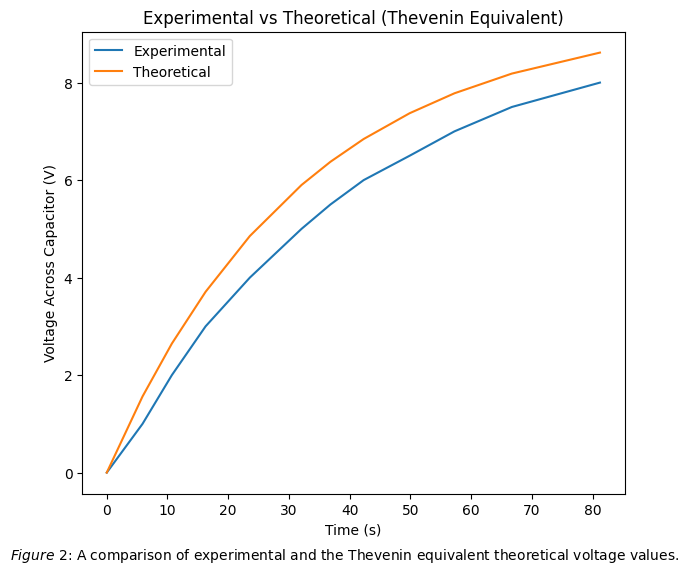

In [2]:
thevenin_V_C = 9.375*(1-np.exp(-time_taken/32.3125))
plt.figure(figsize=(7, 6))
plt.plot(time_taken, voltage_across_capacitor)
plt.plot(time_taken, thevenin_V_C)
plt.xlabel("Time (s)"); plt.ylabel("Voltage Across Capacitor (V)")
plt.title("Experimental vs Theoretical (Thevenin Equivalent)")
plt.legend(["Experimental", "Theoretical"])
caption = r"$\it{Figure~2}$: A comparison of experimental and the Thevenin equivalent theoretical voltage values."
plt.figtext(0.5, 0.001, caption, wrap=True, horizontalalignment='center', fontsize=10);

The curves are much more similar compared to the previous graph. At 81.23 seconds, the experimental and theoretical values are 8 and 8.61607 volts, respectively, resulting in an approximate 7.15 percentage error.
Using the Circuit Sandbox [2], we obtain a very similar curve showcased above, almost identical:

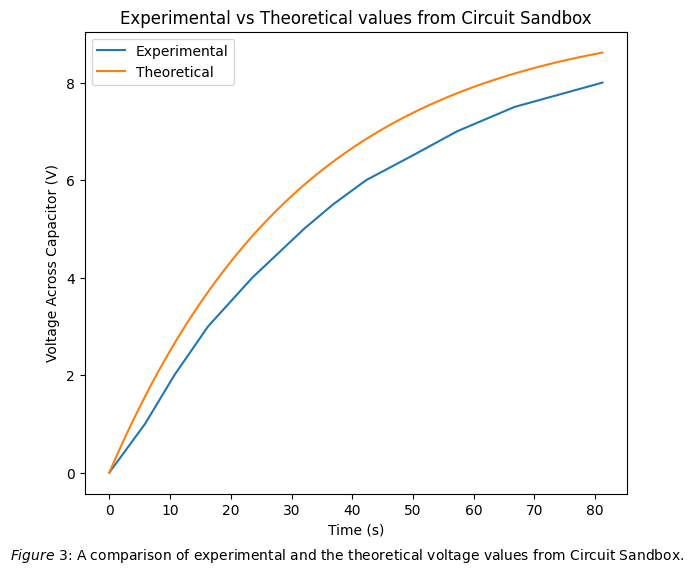

In [3]:
transient_analysis = np.genfromtxt("data.csv", delimiter=",", skip_header=1, usecols=(0, 1))
plt.figure(figsize=(7, 6))
plt.plot(time_taken, voltage_across_capacitor)
plt.plot(transient_analysis[:,0], transient_analysis[:,1])
plt.xlabel("Time (s)"); plt.ylabel("Voltage Across Capacitor (V)")
plt.title("Experimental vs Theoretical values from Circuit Sandbox")
plt.legend(["Experimental", "Theoretical"])
caption = r"$\it{Figure~3}$: A comparison of experimental and the theoretical voltage values from Circuit Sandbox."
plt.figtext(0.5, 0.001, caption, wrap=True, horizontalalignment='center', fontsize=10);

Using the same time value as before, the y axis reads 8 and 8.61617 volts (~7.15% error as well).
The above transient analysis was obtained from the Thevenin circuit below:
<figure style="margin-left: 0; margin-right: auto;">
  <img src="thevenin_circuit.png" style="width:50%; display:block; margin-left:0;">
  <figcaption style="margin-left:0;">
    <em>Figure 4.</em> The Thevenin equivalent circuit used in the analysis.
  </figcaption>
</figure>

# Section E11.5
The theoretical equation for the circuit current can be derived by differentiation:
$$I(t) = C\frac{dV_{c}(t)}{dt} = \frac{V_{in}}{R}e^{- \frac{t}{RC}} \tag{5}$$

$$I(t) = \frac{30}{2.2*10^{6}}*e^{- \frac{t}{103.4}} \tag{6}$$

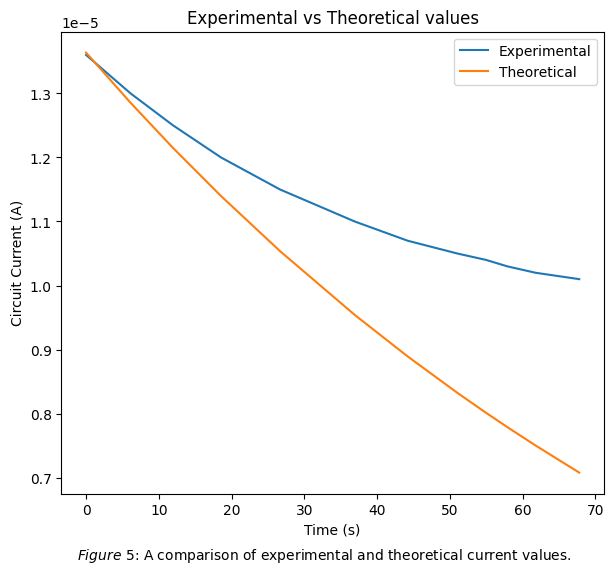

In [4]:
circuit_current = np.array([13.6, 13, 12.5, 12, 11.5, 11, 10.7, 10.5, 10.4, 10.3, 10.2, 10.1]) * 10**-6
time_for_current_to_fall = np.array([0, 6.11, 11.96, 18.54, 26.65, 36.92, 44.19, 51.03, 54.97, 57.88, 61.75, 67.77])
theoretical_I = (30/(2.2*10**6)) * np.exp(-time_for_current_to_fall/103.4)
plt.figure(figsize=(7, 6))
plt.plot(time_for_current_to_fall, circuit_current)
plt.plot(time_for_current_to_fall, theoretical_I)
plt.xlabel("Time (s)"); plt.ylabel("Circuit Current (A)")
plt.title("Experimental vs Theoretical values")
plt.legend(["Experimental", "Theoretical"])
caption = r"$\it{Figure~5}$: A comparison of experimental and theoretical current values."
plt.figtext(0.5, 0.001, caption, wrap=True, horizontalalignment='center', fontsize=10);

Again, the curves start at very similar values (1.36E-05 and 1.36364E-05) but diverge wildly as time progresses. For example, at the 67.77-second mark, the experimental and theoretical voltages are 1.01E-05 and 7.08E-06, resulting in a percentage error of around -42.7%.
We can achieve a closer theoretical curve by deriving the current
through the circuit as a function of time that accounts for the
oscilloscope's impedance:

$$i(t) = \frac{V}{R_{1} + R_{2}}\left( 1 - e^{- \frac{\alpha t}{R_{1}C}} \right) + \frac{V}{R_{1}}e^{- \frac{\alpha t}{R_{1C}}} \tag{7}$$

where α is:

$$\alpha = \frac{R_{1}}{R_{2}} + 1 \tag{8}$$

Plotting this equation returns the graph in *Figure 6*.

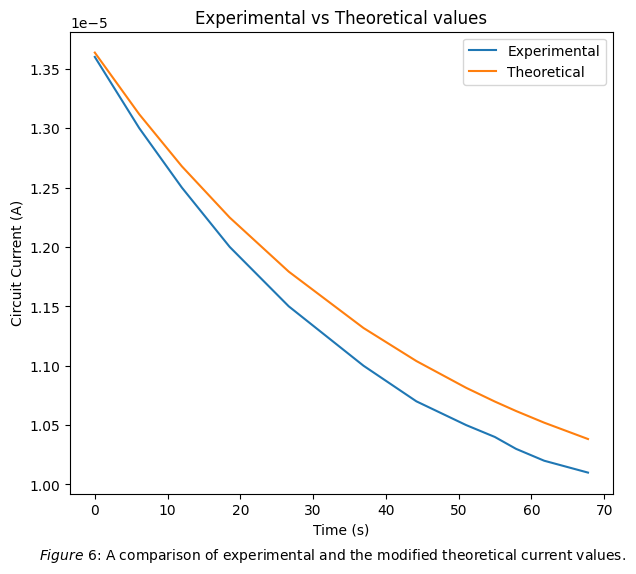

In [5]:
R2 = 1*10**6
alpha = R/R2
modified_theoretical_I = (V_in/(R + R2)) * (1 - np.exp(-alpha*time_for_current_to_fall/(R*C))) + (V_in/R)*np.exp(-alpha*time_for_current_to_fall/(R*C))

plt.figure(figsize=(7, 6))
plt.plot(time_for_current_to_fall, circuit_current)
plt.plot(time_for_current_to_fall, modified_theoretical_I)
plt.xlabel("Time (s)"); plt.ylabel("Circuit Current (A)")
plt.title("Experimental vs Theoretical values")
plt.legend(["Experimental", "Theoretical"])
caption = r"$\it{Figure~6}$: A comparison of experimental and the modified theoretical current values."
plt.figtext(0.5, 0.001, caption, wrap=True, horizontalalignment='center', fontsize=10);

At the 67.77-second mark, the values give a -2.04% error, which is notably accurate.
We can similarly acquire another graph with MIT’s Circuit Sandbox. The circuit used is showcased below in *Figure 7*.
<figure style="margin-left: 0; margin-right: auto;">
  <img src="current.png" style="width:50%; display:block; margin-left:0;">
  <figcaption style="margin-left:0;">
    <em>Figure 4.</em> The circuit used in the analysis. This circuit accounts for the oscillator's impedance.
  </figcaption>
</figure>
The resulting transient analysis was downloaded and imported to be compared with the experimental values.

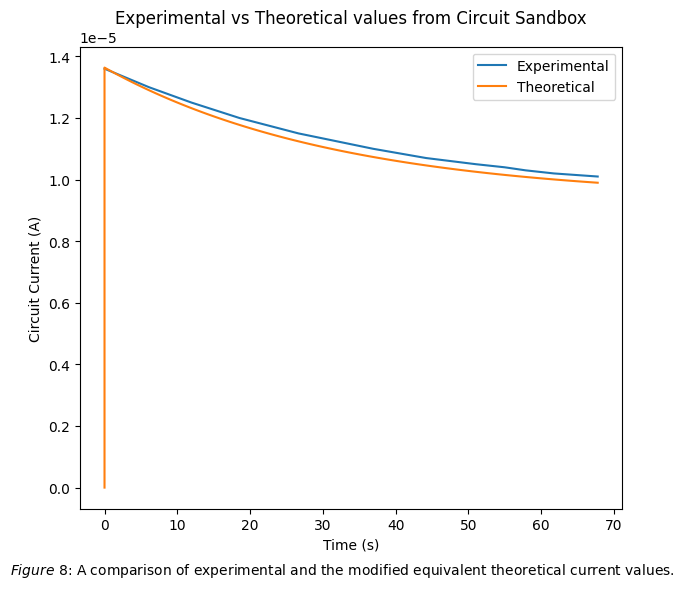

In [6]:
transient_analysis_I = np.genfromtxt("data1.csv", delimiter=",", skip_header=1, usecols=(0, 1))
plt.figure(figsize=(7, 6))
plt.plot(time_for_current_to_fall, circuit_current)
plt.plot(transient_analysis_I[:,0], transient_analysis_I[:,1])
plt.xlabel("Time (s)"); plt.ylabel("Circuit Current (A)")
plt.title("Experimental vs Theoretical values from Circuit Sandbox")
plt.legend(["Experimental", "Theoretical"])
caption = r"$\it{Figure~8}$: A comparison of experimental and the modified equivalent theoretical current values."
plt.figtext(0.5, 0.001, caption, wrap=True, horizontalalignment='center', fontsize=10);

A similar calculation also provides an error of -2.04%.
Discrepancies in the theoretical and experimental values can be attributed to human reaction time and ammeters not being ideal. The former is a random error that could have been mitigated by conducting more tests, yet only one was performed for both cases. The latter is a systematic error that can only be addressed by modelling the impedance of the ammeter as well.
In summary, it is not enough to assume that all components in a circuit are ideal as this can produce significant errors in a theoretical transient analysis (approximately 50% for an ideal oscilloscope, below 10% for a nonideal oscilloscope).

# References
1.	TBS1064 Datasheet. Retrieved 5 March 2022, from https://www.allaboutcircuits.com/electronic-components/datasheet/TBS1064--Tektronix/ 
2.	Circuit Sandbox. (2011). Retrieved 5 March 2022, from https://spinningnumbers.org/circuit-sandbox/ 
